# Semantic Segmentation of Mechanical Parts with U-Net++

7-class pixel-level segmentation (background + hex nut, washer, bolt, ball bearing, spring, o-ring) of 384 × 384 industrial images. **Two U-Net++ models (ResNet-34 and EfficientNet-B1 encoders), both trained from scratch**, are combined with test-time augmentation and a probability-level ensemble.

| | |
|---|---|
| **Architecture** | U-Net++ · ResNet-34 and EfficientNet-B1 encoders · no pretrained weights (Kaiming init) |
| **Loss** | 0.5 · Dice + 0.5 · Cross-Entropy |
| **Training** | AdamW · cosine annealing · mixed precision · early stopping · 100 epochs |
| **Inference** | 6-way TTA → ensemble → missing-class recovery → RLE |
| **Validation Dice** | ResNet-34 **0.9796** · EfficientNet-B1 0.9770 · ensemble 0.9795 |
| **Test Dice** | **0.97960** (private split) · 0.98096 (public split) |

This notebook is the final version (V7) of an iterative study. Test Dice rose from 0.96005 (U-Net baseline) to 0.97960; see the repository README for the full experiment log.

In [ ]:
import numpy as np
import pandas as pd
import os

In [2]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:00


## 1. Setup

### Imports

In [3]:

import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

### Configuration

All experiment settings in one place. `DATASET_DIR` should point to the folder containing `metadata.csv`, `train/` and `test/`.

In [ ]:
# Set this to the local path containing the dataset.
DATASET_DIR = "./Dataset"

IMAGE_SIZE = 384
NUM_CLASSES = 7

BATCH_SIZE = 8
EPOCHS = 100
PATIENCE=15
LEARNING_RATE = 1e-3

SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)

Device : cuda


### Reproducibility

Seeds Python, NumPy and PyTorch (CPU and CUDA) with `SEED = 42`.

In [5]:
import random
def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

## 2. Utilities

- `rle_encode` / `rle_decode`: run-length encoding in **column-major (Fortran) order**. The mask is transposed before flattening, so pixels are numbered down columns.
- `dice` / `mean_dice`: the evaluation metric, the mean Dice over every *(image, foreground class)* pair. Dice is 1 if both masks are empty and 0 if only one is.
- `load_label`: loads masks as integer class maps (0–6). **Never convert masks to RGB**, which would turn class IDs into palette colours.
- `write_submission`: one RLE row per *(image, class)*, 500 × 6 = 3,000 rows.

In [6]:
CLASSES = [
    "hex_nut",
    "washer",
    "bolt",
    "ball_bearing",
    "spring",
    "o_ring"
]

CLASS_ID = {}
SIZE = 384
for i, name in enumerate(CLASSES):
    CLASS_ID[name] = i + 1


def rle_encode(mask):
    """mask: a 384x384 boolean array -> RLE string."""
    px = np.asarray(mask, np.uint8).T.flatten()
    px = np.concatenate([[0], px, [0]])
    runs = np.where(px[1:] != px[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(int(x)) for x in runs)

def rle_decode(rle, size=SIZE):
    """RLE string -> 384x384 uint8 array."""
    m = np.zeros(size * size, np.uint8)
    if not isinstance(rle, str) or not rle.strip():
        return m.reshape(size, size, order="F")
    a = np.asarray(rle.split(), np.int64)
    for s, l in zip(a[0::2], a[1::2]):
        m[s - 1: s - 1 + l] = 1
    return m.reshape(size, size, order="F")

def dice(pred, gt):
    """Dice coefficient for a single binary mask pair."""
    p, g = int(np.sum(pred)), int(np.sum(gt))
    if g == 0:
        return 1.0 if p == 0 else 0.0
    if p == 0:
        return 0.0
    return 2.0 * float(np.logical_and(pred, gt).sum()) / (p + g)

def mean_dice(pred_labels, gt_labels):
    """The official metric: mean over every (image, class) pair."""
    s = []
    for p, g in zip(pred_labels, gt_labels):
        for cid in range(1, len(CLASSES) + 1):
            s.append(dice(p == cid, g == cid))
    return float(np.mean(s))

def load_label(root, fid, split="train"):
    """Loads 0-6 integer label map safely without converting to RGB palette."""
    return np.array(Image.open(f"{root}/{split}/masks/{fid}"))

def write_submission(pred_labels, ids, path):
    """Generates the official submission CSV using RLE string formatting."""
    rows = []
    for fid, lab in zip(ids, pred_labels):
        for c in CLASSES:
            m = lab == CLASS_ID[c]
            rows.append({
                "ImageId_ClassId": f"{fid}_{c}",
                "EncodedPixels": rle_encode(m) if m.any() else "1 1"
            })
    pd.DataFrame(rows).to_csv(path, index=False)
    print(f"Successfully generated submission file at {path}")

## 3. Data

### Augmentation

Geometric transforms are applied jointly to the image and mask. Training uses flips, 90° rotations, shift-scale-rotate (±45°), brightness/contrast, hue/saturation, occasional blur or noise, and coarse dropout. Validation and test images are only normalised with ImageNet statistics.

> **Note:** the warnings below show that the custom `GaussNoise` and `CoarseDropout` arguments are not valid for the installed Albumentations version. Both transforms therefore run with library default settings.

In [7]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=45, p=0.7, border_mode=0),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
    A.OneOf([
        A.MotionBlur(blur_limit=3, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    ], p=0.15),
    A.CoarseDropout(
        max_holes=8, max_height=32, max_width=32, 
        min_holes=1, min_height=8, min_width=8, 
        fill_value=0, mask_fill_value=0, p=0.2
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_23/372477514.py:11: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
/tmp/ipykernel_23/372477514.py:13: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


### Dataset class

Returns `(image, mask)` for training/validation and `(image, image_name)` for test images.

In [8]:
class PartsDataset(Dataset):

    def __init__(self, root_dir, image_ids, split="train", transform=None):

        self.root_dir = root_dir
        self.image_ids = image_ids
        self.split = split
        self.transform = transform

    def __len__(self):

        return len(self.image_ids)

    def __getitem__(self, index):

        image_name = self.image_ids[index]

        image_path = os.path.join(
            self.root_dir,
            self.split,
            "images",
            image_name
        )

        image = np.array(Image.open(image_path))

        if self.split == "train":

            mask = load_label(
                self.root_dir,
                image_name,
                split="train"
            )

            if self.transform:

                sample = self.transform(
                    image=image,
                    mask=mask
                )

                image = sample["image"]
                mask = sample["mask"]

            return image, mask.long()

        else:

            if self.transform:

                sample = self.transform(image=image)
                image = sample["image"]

            return image, image_name

### Metadata

Image IDs, split (train/test), background type, number of parts and the classes present.

In [9]:
metadata = pd.read_csv(
    os.path.join(DATASET_DIR, "metadata.csv")
)

metadata.head()

,id,split,background,n_parts,classes_present
0,img_00000.png,train,wood,10.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring
1,img_00001.png,test,NaN,NaN,NaN
2,img_00002.png,train,concrete,10.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring
3,img_00003.png,train,concrete,7.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring
4,img_00004.png,train,concrete,6.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring


### Train / validation split

A seeded 85 / 15 split gives **1,700 training** and **300 validation** images. Every experiment version used the same split.

In [10]:
train_ids = sorted(
    metadata.loc[
        metadata["split"] == "train",
        "id"
    ].tolist()
)

rng = np.random.default_rng(SEED)

val_size = int(len(train_ids) * 0.15)

val_ids = list(
    rng.choice(
        train_ids,
        size=val_size,
        replace=False
    )
)

train_ids = [
    img
    for img in train_ids
    if img not in set(val_ids)
]

print("Training Images :", len(train_ids))
print("Validation Images :", len(val_ids))

Training Images : 1700
Validation Images : 300


### Visual check of a training sample

Image, ground-truth mask and overlay. Each image contains all six part classes on a textured background.

In [11]:


def show_sample(data_root, image_id):

    image = np.array(Image.open(f"{data_root}/train/images/{image_id}"))
    mask = np.array(Image.open(f"{data_root}/train/masks/{image_id}"))

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))

    ax[0].imshow(image)
    ax[0].set_title("Image")
    ax[0].axis("off")

    img = ax[1].imshow(mask, cmap="nipy_spectral", vmin=0, vmax=6)
    ax[1].set_title("Mask")
    ax[1].axis("off")

    ax[2].imshow(image)
    ax[2].imshow(mask, cmap="nipy_spectral", alpha=0.5, vmin=0, vmax=6)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    cbar = fig.colorbar(img, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_ticks(range(7))
    cbar.set_ticklabels(["background"] + CLASSES)

    plt.show()

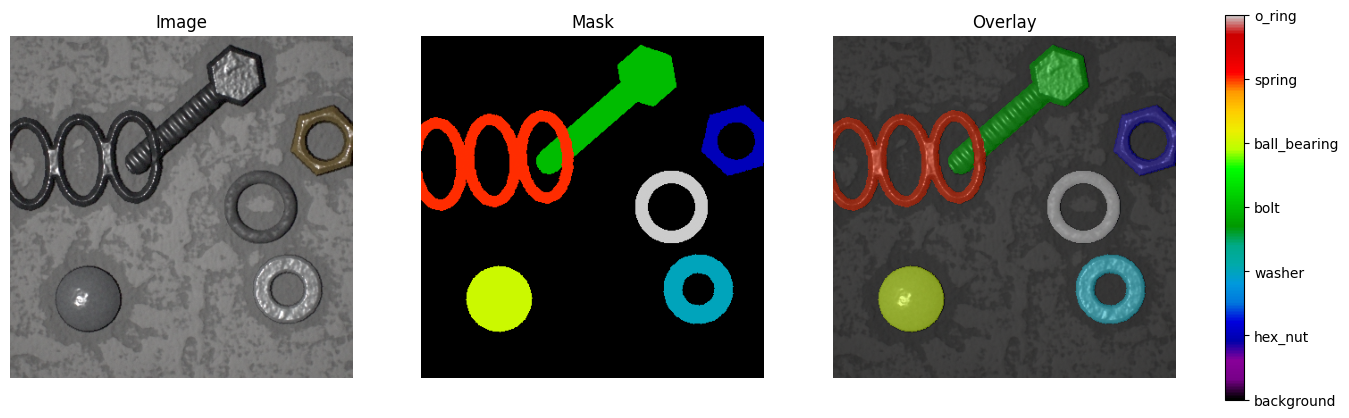

In [12]:
show_sample(DATASET_DIR, train_ids[3])

### Dataset objects

In [13]:
train_dataset = PartsDataset(
    root_dir=DATASET_DIR,
    image_ids=train_ids,
    split="train",
    transform=train_transform
)

val_dataset = PartsDataset(
    root_dir=DATASET_DIR,
    image_ids=val_ids,
    split="train",
    transform=val_transform
)

### Data loaders

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))

Train Batches : 213
Validation Batches : 38


## 4. Model

### U-Net++ without pretrained weights

`encoder_weights=None`: every encoder is trained **from scratch**. This cell is a quick architecture check; the training loop below builds a fresh model for each encoder.

In [15]:
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES
)
model = model.to(DEVICE)
print(model.__class__.__name__)

UnetPlusPlus


### Kaiming initialisation

Convolutional and linear layers use Kaiming normal initialisation (`fan_in`, ReLU) with zero bias, which keeps activation variance stable in deep ReLU networks trained from random initialisation.

In [16]:
def initialize_weights(module):

    if isinstance(module, (nn.Conv2d, nn.Linear)):

        nn.init.kaiming_normal_(
            module.weight,
            mode="fan_in",
            nonlinearity="relu"
        )

        if module.bias is not None:
            nn.init.zeros_(module.bias)


## 5. Loss function

Two losses were compared in a controlled ablation (V5 vs V6, all else fixed):

| Loss | Test Dice (private) |
|---|---:|
| 0.7 · Dice + 0.3 · Focal (V5) | 0.97780 |
| **0.5 · Dice + 0.5 · Cross-Entropy (V6, final)** | **0.97907** |

The Dice + Focal variant is kept below, disabled as a string, for reference. The next cell defines the final Dice + CE loss.

In [17]:
"""class DiceFocalLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
        self.focal = smp.losses.FocalLoss(mode="multiclass", alpha=0.25, gamma=2.0)

    def forward(self, y_pred, y_true):
        return 0.7 * self.dice(y_pred, y_true) + 0.3 * self.focal(y_pred, y_true)

criterion = DiceFocalLoss()"""

'class DiceFocalLoss(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.dice = smp.losses.DiceLoss(mode="multiclass", from_logits=True)\n        self.focal = smp.losses.FocalLoss(mode="multiclass", alpha=0.25, gamma=2.0)\n\n    def forward(self, y_pred, y_true):\n        return 0.7 * self.dice(y_pred, y_true) + 0.3 * self.focal(y_pred, y_true)\n\ncriterion = DiceFocalLoss()'

**Final loss (V6 onwards):** equal-weight Dice + Cross-Entropy.

In [18]:
class DiceCEWithLogitsLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
        self.ce = nn.CrossEntropyLoss()

    def forward(self, y_pred, y_true):
        return 0.5 * self.dice(y_pred, y_true) + 0.5 * self.ce(y_pred, y_true)

criterion = DiceCEWithLogitsLoss()

## 6. Test-time augmentation (6-way)

Each batch is predicted under 6 views: identity, horizontal flip, vertical flip, both flips, 90° rotation and 270° rotation. Each softmax output is mapped back to the original orientation, and the 6 are averaged. Adding the two rotations (V6 → V7) improved test Dice from 0.97907 to 0.97960.

In [19]:
def get_tta_probs(model, images):
    
    with torch.amp.autocast('cuda'):
        p_orig = torch.softmax(model(images), dim=1)
        
        p_h = torch.flip(torch.softmax(model(torch.flip(images, dims=[-1])), dim=1), dims=[-1])
        p_v = torch.flip(torch.softmax(model(torch.flip(images, dims=[-2])), dim=1), dims=[-2])
        p_hv = torch.flip(torch.softmax(model(torch.flip(images, dims=[-1, -2])), dim=1), dims=[-1, -2])
        img_rot90 = torch.rot90(images, k=1, dims=[-2, -1])
        p_r90 = torch.rot90(torch.softmax(model(img_rot90), dim=1), k=-1, dims=[-2, -1])
        img_rot270 = torch.rot90(images, k=3, dims=[-2, -1])
        p_r270 = torch.rot90(torch.softmax(model(img_rot270), dim=1), k=-3, dims=[-2, -1])
        
    return (p_orig + p_h + p_v + p_hv + p_r90 + p_r270) / 6.0


## 7. Training

### One training epoch (mixed precision)

Forward pass under `torch.amp.autocast`, with loss scaling through `GradScaler`.

In [20]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    
    total_loss = 0.0
    
    for images, masks in loader:
        
        images = images.to(DEVICE)
        
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            
            outputs = model(images)
            
            loss = criterion(outputs, masks)
            
        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        
        scaler.update()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

### Validation (with TTA)

Validation uses the **same 6-way TTA** as test inference, so checkpoint selection optimises the real prediction procedure.

In [21]:
def validate(model, loader):
    model.eval()
    predictions = []
    ground_truth = []
    
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(DEVICE)
            
            final_probs = get_tta_probs(model, images)
            predicted_masks = torch.argmax(final_probs, dim=1)
            
            predictions.extend(predicted_masks.cpu().numpy())
            ground_truth.extend(masks.numpy())
            
    return mean_dice(predictions, ground_truth)


### Training loop for one encoder

AdamW (lr 1e-3, weight decay 1e-4), cosine annealing over 100 epochs, early stopping with patience 15, and a checkpoint at the best validation Dice.

In [22]:
def train_encoder(encoder_name):
    print(f"\nTraining Model: {encoder_name.upper()}")
    
    model = smp.UnetPlusPlus(
        encoder_name=encoder_name,
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES
    )
    
    model = model.to(DEVICE)
    model.apply(initialize_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=EPOCHS
    )
    
    scaler = torch.amp.GradScaler('cuda')
    
    best_score = 0.0
    epochs_no_improve = 0
    model_save_path = f"best_unet_{encoder_name}.pth"
    
    history = {
        "train_loss": [],
        "val_dice": []
    }
    
    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_score = validate(model, val_loader)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_dice"].append(val_score)

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Loss: {train_loss:.4f} | "
            f"Dice: {val_score:.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.6f}"
        )

        if val_score > best_score:
            best_score = val_score
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_save_path)
            print("Model saved")
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered for {encoder_name} after {epoch + 1} epochs.")
            break


    torch.cuda.empty_cache()
    
    return model_save_path, history

### Train both encoders

Each encoder is trained independently: its own model, optimiser, schedule, early-stopping counter and checkpoint. Neither run triggered early stopping.

In [23]:
ENCODERS = ["efficientnet-b1", "resnet34"]
saved_models = []
all_histories = {}

for encoder in ENCODERS:
    path, history = train_encoder(encoder)
    saved_models.append(path)
    all_histories[encoder] = history


Training Model: EFFICIENTNET-B1
Epoch 1/100 | Loss: 0.7269 | Dice: 0.2930 | LR: 0.001000
Model saved
Epoch 2/100 | Loss: 0.4496 | Dice: 0.6517 | LR: 0.000999
Model saved
Epoch 3/100 | Loss: 0.3082 | Dice: 0.7909 | LR: 0.000998
Model saved
Epoch 4/100 | Loss: 0.2212 | Dice: 0.8302 | LR: 0.000996
Model saved
Epoch 5/100 | Loss: 0.1741 | Dice: 0.8898 | LR: 0.000994
Model saved
Epoch 6/100 | Loss: 0.1475 | Dice: 0.9026 | LR: 0.000991
Model saved
Epoch 7/100 | Loss: 0.1297 | Dice: 0.9147 | LR: 0.000988
Model saved
Epoch 8/100 | Loss: 0.1192 | Dice: 0.9283 | LR: 0.000984
Model saved
Epoch 9/100 | Loss: 0.1132 | Dice: 0.9324 | LR: 0.000980
Model saved
Epoch 10/100 | Loss: 0.1043 | Dice: 0.9360 | LR: 0.000976
Model saved
Epoch 11/100 | Loss: 0.0981 | Dice: 0.9392 | LR: 0.000970
Model saved
Epoch 12/100 | Loss: 0.0920 | Dice: 0.9466 | LR: 0.000965
Model saved
Epoch 13/100 | Loss: 0.0888 | Dice: 0.9288 | LR: 0.000959
Epoch 14/100 | Loss: 0.0852 | Dice: 0.9474 | LR: 0.000952
Model saved
Epoch 15

### Training curves

ResNet-34 learns faster and finishes higher (best validation Dice 0.9796 vs 0.9770).

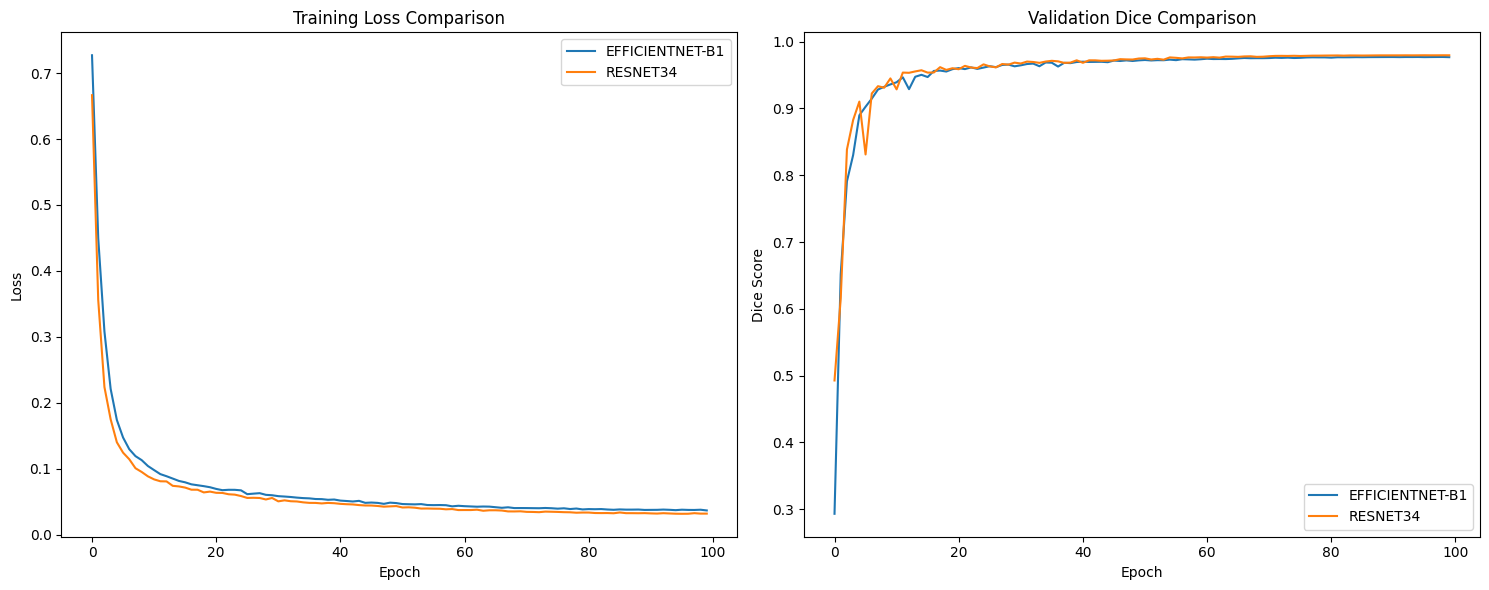

In [24]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for encoder, hist in all_histories.items():
    plt.plot(hist["train_loss"], label=f"{encoder.upper()}")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for encoder, hist in all_histories.items():
    plt.plot(hist["val_dice"], label=f"{encoder.upper()}")
plt.title("Validation Dice Comparison")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()

plt.tight_layout()
plt.show()



## 8. Ensemble evaluation on validation

### Load the best checkpoint of each encoder

In [25]:
print("Evaluating Final Ensemble on Validation Set")


model_1 = smp.UnetPlusPlus(encoder_name=ENCODERS[0], 
                           encoder_weights=None, 
                           in_channels=3, 
                           classes=NUM_CLASSES).to(DEVICE)
model_1.load_state_dict(torch.load(saved_models[0], map_location=DEVICE))
model_1.eval()

model_2 = smp.UnetPlusPlus(encoder_name=ENCODERS[1], 
                           encoder_weights=None, 
                           in_channels=3, 
                           classes=NUM_CLASSES).to(DEVICE)
model_2.load_state_dict(torch.load(saved_models[1], map_location=DEVICE))
model_2.eval();

Evaluating Final Ensemble on Validation Set


### Ensemble + missing-class recovery

Probabilities are combined as 0.4 · EfficientNet-B1 + 0.6 · ResNet-34. If a foreground class has **no** predicted pixels in an image, the pixels with probability > 0.20 for that class are assigned to it, keeping at most the 150 most confident. This avoids a guaranteed Dice of 0 for that image-class pair.

Result: **0.9795** ensemble validation Dice, on par with ResNet-34 alone (0.9796).

In [26]:
val_preds = []
val_gt = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(DEVICE)
        
        probs_1 = get_tta_probs(model_1, images)
        probs_2 = get_tta_probs(model_2, images)
        
        ensemble_probs = (0.4 * probs_1) + (0.6 * probs_2)
        preds = torch.argmax(ensemble_probs, dim=1)
        
        for batch_idx in range(preds.shape[0]):
            for class_idx in range(1, NUM_CLASSES):
                if (preds[batch_idx] == class_idx).sum() == 0:
                    flat_probs = ensemble_probs[batch_idx, class_idx].view(-1)
                    mask = flat_probs > 0.20
                    if mask.sum() > 0:
                        idx = torch.where(mask)[0]
                        if len(idx) > 150:
                            vals = flat_probs[idx]
                            _, order = torch.topk(vals, 150)
                            idx = idx[order]
                        preds[batch_idx].view(-1)[idx] = class_idx
                        
        val_preds.extend(preds.cpu().numpy())
        val_gt.extend(masks.numpy())

ensemble_val_score = mean_dice(val_preds, val_gt)
print(f"Final Ensemble Validation Dice Score : {ensemble_val_score:.4f}\n")

Final Ensemble Validation Dice Score : 0.9795



## 9. Test inference

### Test data

In [27]:
test_ids = sorted(
    metadata.loc[
        metadata["split"] == "test",
        "id"
    ].tolist()
)

test_dataset = PartsDataset(
    root_dir=DATASET_DIR,
    image_ids=test_ids,
    split="test",
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

### Ensemble prediction

6-way TTA for each model, an equal-weight (50/50) probability ensemble, argmax, then missing-class recovery.

In [28]:
predicted_masks = []
original_images = []
image_names = []

with torch.no_grad():
    for images, ids in test_loader:
        original_images.extend(images.cpu())
        images = images.to(DEVICE)
        
        probs_1 = get_tta_probs(model_1, images)
        probs_2 = get_tta_probs(model_2, images)
        
        ensemble_probs = (probs_1 + probs_2) / 2.0
        
        preds = torch.argmax(ensemble_probs, dim=1)
        
        for batch_idx in range(preds.shape[0]):
            for class_idx in range(1, NUM_CLASSES):
                if (preds[batch_idx] == class_idx).sum() == 0:
                    
                    flat_probs = ensemble_probs[batch_idx, class_idx].view(-1)
                    mask = flat_probs > 0.20
                    
                    if mask.sum() > 0:
                        idx = torch.where(mask)[0]
                        if len(idx) > 150:
                            vals = flat_probs[idx]
                            _, order = torch.topk(vals, 150)
                            idx = idx[order]
                        preds[batch_idx].view(-1)[idx] = class_idx

        predicted_masks.extend(preds.cpu().numpy())
        image_names.extend(ids)

### Visual check of a test prediction

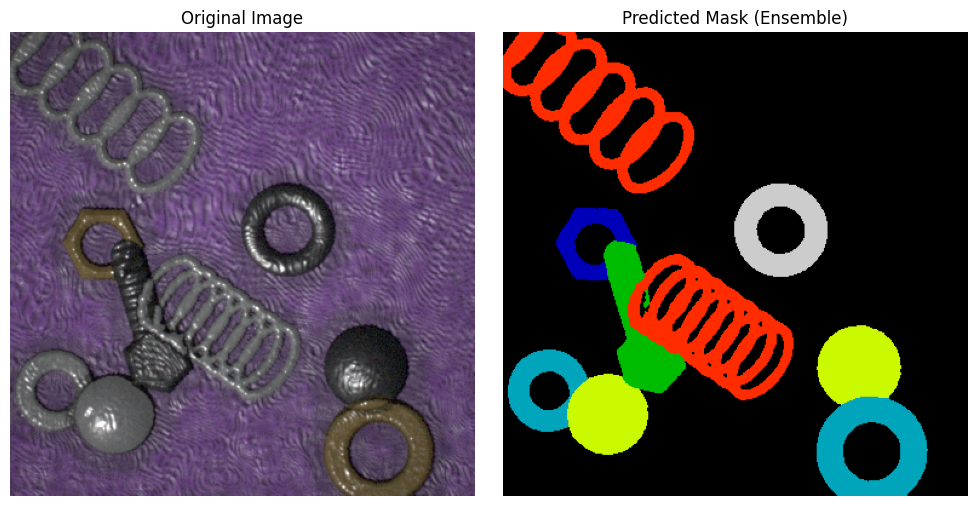

In [29]:
idx = 0  
img = original_images[idx].permute(1, 2, 0).numpy()

img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)
mask = predicted_masks[idx]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(mask, cmap="nipy_spectral", vmin=0, vmax=6)
ax[1].set_title("Predicted Mask (Ensemble)")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 10. Submission

RLE-encode each *(image, class)* mask: 500 images × 6 classes = **3,000 rows**.

In [30]:
write_submission(
    predicted_masks,
    image_names,
    "submission.csv"
)

submission = pd.read_csv("submission.csv")

print(submission.head(12))
print()
print("Submission Shape :", submission.shape)

Successfully generated submission file at submission.csv
               ImageId_ClassId  \
0        img_00001.png_hex_nut   
1         img_00001.png_washer   
2           img_00001.png_bolt   
3   img_00001.png_ball_bearing   
4         img_00001.png_spring   
5         img_00001.png_o_ring   
6        img_00005.png_hex_nut   
7         img_00005.png_washer   
8           img_00005.png_bolt   
9   img_00005.png_ball_bearing   
10        img_00005.png_spring   
11        img_00005.png_o_ring   

                                        EncodedPixels  
0   17069 6 17451 10 17833 13 18215 18 18597 21 18...  
1   1829 11 2208 21 2590 26 2971 31 3353 34 3736 3...  
2   32056 5 32437 12 32819 18 33202 25 33585 30 33...  
3   20665 9 21044 20 21425 26 21807 30 22189 35 22...  
4   21 27 404 29 786 32 1168 35 1551 36 1933 39 23...  
5   73502 13 73883 21 74265 26 74646 31 75028 35 7...  
6   75478 6 75851 18 76221 33 76599 39 76982 41 77...  
7   36 71 420 72 803 74 1187 74 1570 33 1612 34 19..

## Results

| Model | Validation Dice |
|---|---:|
| U-Net++ · EfficientNet-B1 | 0.9770 |
| U-Net++ · ResNet-34 | **0.9796** |
| Ensemble (0.4 / 0.6) + recovery | 0.9795 |

| Test split | Dice |
|---|---:|
| Private | **0.97960** |
| Public | 0.98096 |

The final validation Dice (0.9795) closely matches the private test Dice (0.97960). ResNet-34 outperformed EfficientNet-B1 when both were trained from scratch.